# Combined CRISPR + PHIST host assignment

Assign a predicted host per virus from CRISPR (cascade: `0mm → ≤1mm`) and PHIST (`Containment ≥ 0.2`):

1. Start at **species**, then fall back to **genus**, then **family**
2. At each rank, consider methods with a top-taxon consensus of **≥70%**
3. **Species** requires **≥2 connections**; genus/family allow a single connection
4. Prefer the method with **more connections** (CRISPR wins ties)
5. Stop at the first (lowest) rank that yields an assignment

Report annotation and UHGV-agreement rates overall and by assignment rank (vs UHGV final host).

In [95]:
### Load packages
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns

plt.rcParams.update({'font.size': 14})

In [96]:
### Paths and parameters
CRISPR_TSV = '../figure_1/uhgv_hq_hc_results/uhvdb_2026-03-23/uhvdb_crispr.tsv.gz'
PHIST_TSV = '../figure_1/uhgv_hq_hc_results/uhvdb_2026-03-23/uhvdb_phist.tsv.gz'
MAPPING_TSV = '../figure_1/uhgv_hq_hc_results/uhvdb_2026-03-23/uhvdb_mapping.tsv.gz'
SPECIES_INFO = '../figure_1/uhgv_hq_hc_results/uhvdb_2026-03-23/uhvdb_species_info.tsv.gz'
ICTV_TSV = '../figure_1/uhgv_hq_hc_results/uhvdb_2026-03-23/uhvdb_ictv_taxonomy.tsv.gz'
AAI_CLUSTER_TSV = '../figure_1/uhgv_hq_hc_results/uhvdb_2026-03-23/uhvdb_aaicluster.tsv.gz'
PHIST_SLIM_PARQUET = Path('uhvdb_phist_slim.parquet')

RANKS = ['species', 'genus', 'family']
MIN_AGREEMENT = 0.7
MIN_CONNECTIONS_SPECIES = 2  # species requires multiple connections; genus/family allow 1
PHIST_CONTAINMENT = 0.2
OUT_TSV = 'uhvdb_combined_host_assignments.tsv.gz'

# ICTV classes that exclusively (or near-exclusively) infect prokaryotes.
# Remaining classes in the UHVDB ICTV table contain eukaryotic-host viruses.
PROKARYOTE_ONLY_ICTV_CLASSES = {
    'Caudoviricetes',
    'Malgrandaviricetes',  # Microviridae
    'Tectiliviricetes',    # Tectiviridae
    'Leviviricetes',       # Fiersviridae
    'Faserviricetes',      # Inoviridae
}

### CRISPR cascade predictions (0mm → ≤1mm)

Build top calls and detected-taxon sets. Cascade evidence: use 0-mismatch hits when present, otherwise ≤1-mismatch.

In [97]:
def crispr_counts(lf, max_mismatches, ranks=RANKS):
    """Per-virus connection counts at each rank for one mismatch cutoff."""
    base = lf.filter(pl.col('N mismatches') <= max_mismatches)
    parts = []
    for rank in ranks:
        parts.append(
            base
            .filter(pl.col(rank).is_not_null() & (pl.col(rank).str.strip_chars() != ''))
            .group_by(['uhvdb_id', rank])
            .agg(pl.len().alias('connections'))
            .rename({rank: 'taxon'})
            .with_columns([
                pl.col('taxon').str.strip_chars().alias('taxon'),
                pl.lit(rank).alias('rank'),
                pl.lit(max_mismatches).alias('max_mismatches'),
            ])
        )
    return pl.concat(parts).collect(engine='streaming')


def summarize_counts(counts):
    """Top taxon + detected taxon list from connection counts."""
    return (
        counts
        .group_by(['uhvdb_id', 'rank'])
        .agg([
            pl.col('connections').sum().alias('total_connections'),
            pl.col('connections').max().alias('max_connections'),
            pl.col('taxon').sort_by('connections', descending=True).first().alias('taxon'),
            pl.col('taxon').unique().alias('detected_taxa'),
        ])
        .with_columns(
            (pl.col('max_connections') / pl.col('total_connections')).alias('agreement')
        )
    )


crispr_lf = pl.scan_csv(CRISPR_TSV, separator='\t').select(
    ['uhvdb_id', 'species', 'genus', 'family', 'N mismatches']
)
print('Building CRISPR connection counts...')
counts_0mm = crispr_counts(crispr_lf, max_mismatches=0)
counts_1mm = crispr_counts(crispr_lf, max_mismatches=1)

sum_0mm = summarize_counts(counts_0mm).with_columns(pl.lit('0mm').alias('evidence'))
sum_1mm = summarize_counts(counts_1mm).with_columns(pl.lit('<=1mm_fallback').alias('evidence'))

# Cascade: prefer 0mm summary; fall back to ≤1mm when no 0mm call exists
crispr_preds = pl.concat([
    sum_0mm,
    sum_1mm.join(sum_0mm.select(['uhvdb_id', 'rank']), on=['uhvdb_id', 'rank'], how='anti'),
], how='vertical_relaxed')

print(
    f'CRISPR cascade: {crispr_preds.height:,} rows, '
    f"{crispr_preds['uhvdb_id'].n_unique():,} viruses"
)
crispr_preds.head(3)

Building CRISPR connection counts...
CRISPR cascade: 433,963 rows, 144,722 viruses


uhvdb_id,rank,total_connections,max_connections,taxon,detected_taxa,agreement,evidence
str,str,u32,u32,str,list[str],f64,str
"""UHVDB-74740""","""genus""",13,11,"""Hominicoprocola""","[""F23-B02"", ""Hominicoprocola""]",0.846154,"""0mm"""
"""UHVDB-135944""","""genus""",2480,1021,"""Lachnospira""","[""Dorea_A"", ""Butyribacter"", … ""Catonella""]",0.411694,"""0mm"""
"""UHVDB-145079""","""family""",104,104,"""Ruminococcaceae""","[""Ruminococcaceae""]",1.0,"""0mm"""


### PHIST predictions (Containment ≥ 0.2)

Top calls and detected-taxon sets at each rank.

In [98]:
if not PHIST_SLIM_PARQUET.exists():
    (
        pl.scan_csv(
            PHIST_TSV,
            separator='\t',
            schema_overrides={'Containment': pl.Float32},
        )
        .select(['uhvdb_id', 'Containment', 'taxonomy'])
        .rename({'uhvdb_id': 'Target id'})
        .sink_parquet(PHIST_SLIM_PARQUET)
    )
    print(f'Wrote slim cache: {PHIST_SLIM_PARQUET.resolve()}')

phist_hits = pl.scan_parquet(PHIST_SLIM_PARQUET)


def assign_phist_hosts(lf, threshold=PHIST_CONTAINMENT):
    """Top-taxon PHIST calls + detected taxa at species/genus/family."""
    base = (
        lf
        .filter(pl.col('Containment') >= threshold)
        .filter(pl.col('taxonomy').is_not_null() & (pl.col('taxonomy').str.strip_chars() != ''))
        .with_columns([
            pl.col('taxonomy').str.extract(r'(?:^|;)\s*(s__[^;]+)', 1).str.strip_chars().alias('s_token'),
            pl.col('taxonomy').str.extract(r'(?:^|;)\s*(g__[^;]+)', 1).str.strip_chars().alias('g_token'),
            pl.col('taxonomy').str.extract(r'(?:^|;)\s*(f__[^;]+)', 1).str.strip_chars().alias('f_token'),
        ])
    )
    totals = base.group_by('Target id').agg(pl.len().alias('total_connections'))

    parts = []
    for rank, col in [('species', 's_token'), ('genus', 'g_token'), ('family', 'f_token')]:
        counts = (
            base
            .filter(pl.col(col).is_not_null() & (pl.col(col) != '') & (pl.col(col) != f'{rank[0]}__'))
            .group_by(['Target id', col])
            .agg(pl.len().alias('connections'))
            .with_columns(
                pl.col(col).str.replace(r'^[sgf]__', '').alias('taxon')
            )
        )
        parts.append(
            counts
            .group_by('Target id')
            .agg([
                pl.col('connections').max().alias('max_connections'),
                pl.col('taxon').sort_by('connections', descending=True).first().alias('taxon'),
                pl.col('taxon').unique().alias('detected_taxa'),
            ])
            .join(totals, on='Target id', how='inner')
            .with_columns([
                (pl.col('max_connections') / pl.col('total_connections')).alias('agreement'),
                pl.lit(rank).alias('rank'),
                pl.lit(threshold).alias('containment_threshold'),
            ])
            .rename({'Target id': 'uhvdb_id'})
            .select([
                'uhvdb_id', 'total_connections', 'max_connections',
                'taxon', 'detected_taxa', 'agreement', 'rank', 'containment_threshold',
            ])
        )
    return pl.concat(parts).collect(engine='streaming')


print(f'Building PHIST consensus at Containment >= {PHIST_CONTAINMENT}...')
phist_preds = assign_phist_hosts(phist_hits, threshold=PHIST_CONTAINMENT)
print(
    f'PHIST: {phist_preds.height:,} rows, '
    f"{phist_preds['uhvdb_id'].n_unique():,} viruses"
)
phist_preds.head(3)

Building PHIST consensus at Containment >= 0.2...
PHIST: 361,659 rows, 120,553 viruses


uhvdb_id,total_connections,max_connections,taxon,detected_taxa,agreement,rank,containment_threshold
str,u32,u32,str,list[str],f64,str,f64
"""UHVDB-116520""",690,99,"""Agathobacter rectalis""","[""Bariatricus comes"", ""Blautia_A sp900066335"", … ""CAG-882 sp003486385""]",0.143478,"""species""",0.2
"""UHVDB-31132""",11,10,"""CAG-170 sp003516765""","[""CAG-170 sp000432135"", ""CAG-170 sp003516765""]",0.909091,"""species""",0.2
"""UHVDB-156781""",1742,598,"""Phocaeicola vulgatus""","[""Bacteroides uniformis"", ""Bacteroides xylanisolvens"", … ""Bacteroides intestinalis_A""]",0.343284,"""species""",0.2


### Combine method calls and assign hosts

At each rank (species → genus → family): among methods with ≥70% consensus, pick more connections (CRISPR on ties). Species additionally requires ≥2 connections. Stop at the first rank that assigns.

In [99]:
def _prep_method(df, method):
    return (
        df
        .select([
            'uhvdb_id', 'rank', 'taxon', 'detected_taxa',
            'agreement', 'total_connections', 'max_connections',
        ])
        .rename({
            'taxon': f'taxon_{method}',
            'detected_taxa': f'detected_{method}',
            'agreement': f'agreement_{method}',
            'total_connections': f'n_conn_{method}',
            'max_connections': f'n_top_{method}',
        })
    )


combined = (
    _prep_method(crispr_preds, 'crispr')
    .join(_prep_method(phist_preds, 'phist'), on=['uhvdb_id', 'rank'], how='full', coalesce=True)
)

print(f'Combined method table: {combined.height:,} virus×rank rows')
print(f"Viruses with any CRISPR and/or PHIST call: {combined['uhvdb_id'].n_unique():,}")
combined.head(3)

Combined method table: 449,976 virus×rank rows
Viruses with any CRISPR and/or PHIST call: 150,032


uhvdb_id,rank,taxon_crispr,detected_crispr,agreement_crispr,n_conn_crispr,n_top_crispr,taxon_phist,detected_phist,agreement_phist,n_conn_phist,n_top_phist
str,str,str,list[str],f64,u32,u32,str,list[str],f64,u32,u32
"""UHVDB-74740""","""genus""","""Hominicoprocola""","[""F23-B02"", ""Hominicoprocola""]",0.846154,13,11,"""CAG-170""","[""Dysosmobacter"", ""Flavonifractor"", … ""F23-B02""]",0.285714,7,2
"""UHVDB-135944""","""genus""","""Lachnospira""","[""Dorea_A"", ""Butyribacter"", … ""Catonella""]",0.411694,2480,1021,"""Lachnospira""","[""Butyribacter"", ""Lachnospira"", … ""Coprococcus_A""]",0.289617,183,53
"""UHVDB-145079""","""family""","""Ruminococcaceae""","[""Ruminococcaceae""]",1.0,104,104,"""Ruminococcaceae""","[""Ruminococcaceae""]",1.0,21,21


In [100]:
ASSIGNMENT_SCHEMA = {
    'uhvdb_id': pl.String,
    'rank': pl.String,
    'host_taxon': pl.String,
    'method': pl.String,
    'agreement': pl.Float64,
    'n_connections': pl.Int64,
    'n_conn_crispr': pl.Int64,
    'n_conn_phist': pl.Int64,
    'agreement_crispr': pl.Float64,
    'agreement_phist': pl.Float64,
}


def _pick_method(row, min_connections=1):
    """Among methods with ≥70% consensus and ≥min_connections, pick more connections; CRISPR wins ties."""
    candidates = []
    if (
        row['taxon_crispr'] is not None
        and row['agreement_crispr'] is not None
        and row['agreement_crispr'] >= MIN_AGREEMENT
        and (row['n_conn_crispr'] or 0) >= min_connections
    ):
        candidates.append(('crispr', row['n_conn_crispr'] or 0, row['taxon_crispr'], row['agreement_crispr']))
    if (
        row['taxon_phist'] is not None
        and row['agreement_phist'] is not None
        and row['agreement_phist'] >= MIN_AGREEMENT
        and (row['n_conn_phist'] or 0) >= min_connections
    ):
        candidates.append(('phist', row['n_conn_phist'] or 0, row['taxon_phist'], row['agreement_phist']))
    if not candidates:
        return None

    # More connections first; CRISPR before PHIST on ties
    candidates.sort(key=lambda x: (-x[1], 0 if x[0] == 'crispr' else 1))
    method, n_conn, taxon, agree = candidates[0]

    if len(candidates) == 2 and candidates[0][2] == candidates[1][2]:
        method = 'both'
        n_conn = (row['n_conn_crispr'] or 0) + (row['n_conn_phist'] or 0)
        agree = min(row['agreement_crispr'], row['agreement_phist'])

    return method, taxon, agree, n_conn


def assign_at_rank(df, rank, min_connections=1):
    """Assign viruses at one rank using max-connection ≥70% consensus (CRISPR ties)."""
    assigned = []
    for row in df.filter(pl.col('rank') == rank).to_dicts():
        picked = _pick_method(row, min_connections=min_connections)
        if picked is None:
            continue
        method, taxon, agree, n_conn = picked
        assigned.append({
            'uhvdb_id': row['uhvdb_id'],
            'rank': rank,
            'host_taxon': taxon,
            'method': method,
            'agreement': agree,
            'n_connections': n_conn,
            'n_conn_crispr': row['n_conn_crispr'],
            'n_conn_phist': row['n_conn_phist'],
            'agreement_crispr': row['agreement_crispr'],
            'agreement_phist': row['agreement_phist'],
        })
    return pl.DataFrame(assigned, schema=ASSIGNMENT_SCHEMA) if assigned else pl.DataFrame(schema=ASSIGNMENT_SCHEMA)


# Lowest rank with a ≥70% consensus wins (species → genus → family)
# Species requires multiple connections; genus/family allow a single connection
species_hosts = assign_at_rank(combined, 'species', min_connections=MIN_CONNECTIONS_SPECIES)
remaining = combined.join(species_hosts.select('uhvdb_id'), on='uhvdb_id', how='anti')
genus_hosts = assign_at_rank(remaining, 'genus', min_connections=1)
remaining = remaining.join(genus_hosts.select('uhvdb_id'), on='uhvdb_id', how='anti')
family_hosts = assign_at_rank(remaining, 'family', min_connections=1)

host_assignments = pl.concat([
    species_hosts, genus_hosts, family_hosts
], how='vertical_relaxed').sort(['rank', 'uhvdb_id'])

print(f'Total viruses with a host assignment: {host_assignments.height:,}')
print('\nBy rank:')
print(
    host_assignments
    .group_by('rank')
    .agg(pl.len().alias('n_viruses'))
    .sort('rank')
)
print('\nBy method (winning evidence):')
print(host_assignments['method'].value_counts())
host_assignments.head(5)

Total viruses with a host assignment: 144,080

By rank:
shape: (3, 2)
┌─────────┬───────────┐
│ rank    ┆ n_viruses │
│ ---     ┆ ---       │
│ str     ┆ u32       │
╞═════════╪═══════════╡
│ family  ┆ 18256     │
│ genus   ┆ 45715     │
│ species ┆ 80109     │
└─────────┴───────────┘

By method (winning evidence):
shape: (3, 2)
┌────────┬───────┐
│ method ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ crispr ┆ 60298 │
│ both   ┆ 51697 │
│ phist  ┆ 32085 │
└────────┴───────┘


uhvdb_id,rank,host_taxon,method,agreement,n_connections,n_conn_crispr,n_conn_phist,agreement_crispr,agreement_phist
str,str,str,str,f64,i64,i64,i64,f64,f64
"""UHVDB-1""","""family""","""CAG-508""","""crispr""",1.0,15,15,null,1.0,null
"""UHVDB-100""","""family""","""Bacteroidaceae""","""phist""",0.875,8,23,8,0.652174,0.875
"""UHVDB-100004""","""family""","""Lachnospiraceae""","""both""",0.994595,991,806,185,0.997519,0.994595
"""UHVDB-100038""","""family""","""Oscillospiraceae""","""both""",1.0,114,3,111,1.0,1.0
"""UHVDB-100039""","""family""","""UBA660""","""crispr""",1.0,20,20,null,1.0,null


In [101]:
### Write assignments + species-cluster coverage
host_assignments.write_csv(OUT_TSV, separator='\t', compression='gzip')
print(f'Wrote {OUT_TSV}')

species_info = (
    pl.read_csv(SPECIES_INFO, separator='\t')
    .select(['uhvdb_id', 'cluster_id', 'votu_rep'])
)
n_clusters = species_info['cluster_id'].n_unique()

cluster_rows = []
for label, hosts in [
    ('all assignments', host_assignments),
    *[(f'{rank} only', host_assignments.filter(pl.col('rank') == rank)) for rank in RANKS],
]:
    n_clusters_with = (
        species_info
        .join(hosts.select('uhvdb_id'), on='uhvdb_id', how='inner')
        ['cluster_id'].n_unique()
    )
    cluster_rows.append({
        'set': label,
        'n_viruses': hosts.height,
        'n_clusters_with_pred': n_clusters_with,
        'percent_clusters': 100 * n_clusters_with / n_clusters,
    })

cluster_summary = pl.DataFrame(cluster_rows)
print(f'Total species clusters: {n_clusters:,}')
cluster_summary

Wrote uhvdb_combined_host_assignments.tsv.gz
Total species clusters: 53,595


set,n_viruses,n_clusters_with_pred,percent_clusters
str,i64,i64,f64
"""all assignments""",144080,48608,90.695028
"""species only""",80109,32895,61.376994
"""genus only""",45715,15202,28.364586
"""family only""",18256,1995,3.722362


### Benchmark vs UHGV HQ final predicted hosts (GTDB-harmonized)

Compare against UHGV's final host (`host_lineage_gtdb_r207`, CRISPR or PHIST via `host_prediction_method`).
Report **annotation rate** and **agreement rate** overall and by assignment rank.
Annotation rates use the shared denominator: HQ genomes present in both UHGV and UHVDB (`both_methods`).

In [102]:
### Load UHGV HQ + remap r207 → r226 host names (shared genomes)
GTDB_TAX_DIR = Path('gtdb_tax')
GTDB_FILES = {
    'r207': [
        'https://data.ace.uq.edu.au/public/gtdb/data/releases/release207/207.0/bac120_taxonomy_r207.tsv.gz',
        'https://data.ace.uq.edu.au/public/gtdb/data/releases/release207/207.0/ar53_taxonomy_r207.tsv.gz',
    ],
    'r226': [
        'https://data.ace.uq.edu.au/public/gtdb/data/releases/release226/226.0/bac120_taxonomy_r226.tsv.gz',
        'https://data.ace.uq.edu.au/public/gtdb/data/releases/release226/226.0/ar53_taxonomy_r226.tsv.gz',
    ],
}


def _ensure_gtdb_file(url: str) -> Path:
    dest = GTDB_TAX_DIR / Path(url).name
    if not dest.exists():
        import urllib.request
        print(f'Downloading {dest.name} ...')
        urllib.request.urlretrieve(url, dest)
    return dest


def _load_gtdb_taxonomy(urls):
    frames = []
    for url in urls:
        path = _ensure_gtdb_file(url)
        frames.append(
            pl.read_csv(path, separator='\t', has_header=False, new_columns=['accession', 'lineage'])
        )
    return (
        pl.concat(frames)
        .with_columns(
            pl.col('accession')
            .str.replace(r'^(RS_|GB_)', '')
            .str.replace(r'\.\d+$', '')
            .alias('gid')
        )
    )


def _rank_token(lineage_col: str, rank_prefix: str) -> pl.Expr:
    return (
        pl.when(pl.col(lineage_col).str.contains(f';{rank_prefix}__'))
        .then(
            pl.col(lineage_col)
            .str.split(f';{rank_prefix}__').list.get(-1)
            .str.split(';').list.get(0)
        )
        .otherwise(None)
    )


def build_r207_to_r226_map(rank_prefix: str) -> pl.DataFrame:
    left = r207_tax.select(['gid', _rank_token('lineage', rank_prefix).alias('r207')])
    right = r226_tax.select(['gid', _rank_token('lineage', rank_prefix).alias('r226')])
    return (
        left.join(right, on='gid', how='inner')
        .filter(pl.col('r207').is_not_null() & pl.col('r226').is_not_null())
        .group_by(['r207', 'r226'])
        .agg(pl.len().alias('n_genomes'))
        .sort(['r207', 'n_genomes'], descending=[False, True])
        .unique(subset=['r207'], keep='first')
        .select(['r207', 'r226', 'n_genomes'])
    )


hq_votus = (
    pl.read_csv(
        '../figure_s6/votus_metadata_extended.tsv',
        null_values='NULL',
        separator='\t',
        ignore_errors=True,
        columns=[
            'uhgv_genome',
            'checkv_completeness',
            'viral_confidence',
            'host_lineage_gtdb_r207',
            'host_prediction_method',
        ],
    )
    .filter(
        (pl.col('checkv_completeness') >= 90)
        & (pl.col('viral_confidence') == 'Confident')
    )
    .with_columns([
        pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';s__'))
            .then(pl.col('host_lineage_gtdb_r207').str.split(';s__').list[-1].str.split(';').list[0])
            .otherwise(None)
            .alias('host_species'),
        pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';g__'))
            .then(pl.col('host_lineage_gtdb_r207').str.split(';g__').list[-1].str.split(';').list[0])
            .otherwise(None)
            .alias('host_genus'),
        pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';f__'))
            .then(pl.col('host_lineage_gtdb_r207').str.split(';f__').list[-1].str.split(';').list[0])
            .otherwise(None)
            .alias('host_family'),
    ])
)

r207_tax = _load_gtdb_taxonomy(GTDB_FILES['r207'])
r226_tax = _load_gtdb_taxonomy(GTDB_FILES['r226'])
rank_prefix = {'species': 's', 'genus': 'g', 'family': 'f'}
gtdb_maps = {rank: build_r207_to_r226_map(prefix) for rank, prefix in rank_prefix.items()}

hq_votus = hq_votus.with_columns([
    pl.col('host_species')
        .replace_strict(
            dict(zip(gtdb_maps['species']['r207'].to_list(), gtdb_maps['species']['r226'].to_list())),
            default=pl.col('host_species'),
        )
        .alias('host_species_r226'),
    pl.col('host_genus')
        .replace_strict(
            dict(zip(gtdb_maps['genus']['r207'].to_list(), gtdb_maps['genus']['r226'].to_list())),
            default=pl.col('host_genus'),
        )
        .alias('host_genus_r226'),
    pl.col('host_family')
        .replace_strict(
            dict(zip(gtdb_maps['family']['r207'].to_list(), gtdb_maps['family']['r226'].to_list())),
            default=pl.col('host_family'),
        )
        .alias('host_family_r226'),
])

mapping = (
    pl.scan_csv(MAPPING_TSV, separator='\t')
    .rename({'original_id': 'uhgv_genome', 'new_id': 'uhvdb_id'})
    .with_columns(pl.col('uhgv_genome').str.replace(r'\|provirus.*', ''))
    .collect()
)

n_hq = hq_votus['uhgv_genome'].n_unique()
# Shared denominator: HQ genomes present in both UHGV and UHVDB
both_methods = set(
    mapping.join(hq_votus, on='uhgv_genome', how='inner')['uhgv_genome']
)
n_hq_both = len(both_methods)
print(f'Total UHGV HQ vOTUs: {n_hq:,}')
print(f'HQ vOTUs present in UHGV and UHVDB (denominator): {n_hq_both:,}')

Total UHGV HQ vOTUs: 57,514
HQ vOTUs present in UHGV and UHVDB (denominator): 51,406


In [103]:
def hosts_match_expr(uhgv_col: str, uhvdb_col: str = 'host_taxon', rank: str = 'species') -> pl.Expr:
    exact = pl.col(uhgv_col) == pl.col(uhvdb_col)
    if rank == 'species':
        uhgv_spid = pl.col(uhgv_col).str.extract(r'sp(\d{9})', 1)
        uhvdb_spid = pl.col(uhvdb_col).str.extract(r'sp(\d{9})', 1)
        spid = uhgv_spid.is_not_null() & (uhgv_spid == uhvdb_spid)
        return exact | spid
    return exact


UHGV_HOST_COL = {
    'species': 'host_species_r226',
    'genus': 'host_genus_r226',
    'family': 'host_family_r226',
}

hq_with_assign = (
    hq_votus
    .filter(pl.col('uhgv_genome').is_in(both_methods))
    .join(mapping, on='uhgv_genome', how='inner')
    .join(host_assignments, on='uhvdb_id', how='left')
)


def _benchmark_subset(subset, label):
    n_annotated = subset.filter(pl.col('host_taxon').is_not_null())['uhgv_genome'].n_unique()
    annotation_rate = n_annotated / n_hq_both if n_hq_both > 0 else 0

    tp = fp = n_with_uhgv_ref = 0
    for rank, uhgv_col in UHGV_HOST_COL.items():
        rank_sub = subset.filter(
            (pl.col('rank') == rank) & pl.col(uhgv_col).is_not_null()
        )
        n_with_uhgv_ref += rank_sub.height
        match = hosts_match_expr(uhgv_col, rank=rank)
        tp += rank_sub.filter(match).height
        fp += rank_sub.filter(~match).height

    return {
        'set': label,
        'n_hq_annotated': n_annotated,
        'annotation_rate': annotation_rate,
        'n_with_uhgv_host_ref': n_with_uhgv_ref,
        'tp': tp,
        'fp': fp,
        'agreement_rate': (tp / n_with_uhgv_ref) if n_with_uhgv_ref else None,
    }


bench_rows = [_benchmark_subset(hq_with_assign, 'all assignments')]
for rank in RANKS:
    rank_sub = hq_with_assign.filter(pl.col('rank') == rank)
    bench_rows.append(_benchmark_subset(rank_sub, rank))

benchmark = pl.DataFrame(bench_rows)
print('Annotation + agreement (HQ ∩ UHVDB, vs UHGV final host, r226-mapped):')
print(hq_with_assign.filter(pl.col('host_taxon').is_not_null())['host_prediction_method'].value_counts())
benchmark

Annotation + agreement (HQ ∩ UHVDB, vs UHGV final host, r226-mapped):
shape: (3, 2)
┌────────────────────────┬───────┐
│ host_prediction_method ┆ count │
│ ---                    ┆ ---   │
│ str                    ┆ u32   │
╞════════════════════════╪═══════╡
│ PHIST                  ┆ 6178  │
│ CRISPR                 ┆ 38235 │
│ null                   ┆ 1352  │
└────────────────────────┴───────┘


set,n_hq_annotated,annotation_rate,n_with_uhgv_host_ref,tp,fp,agreement_rate
str,i64,f64,i64,i64,i64,f64
"""all assignments""",45765,0.890266,32250,28695,3420,0.889767
"""species""",30459,0.592518,19885,17294,2456,0.869701
"""genus""",13581,0.264191,10879,9948,931,0.914422
"""family""",1725,0.033556,1486,1453,33,0.977793


In [104]:
### Benchmark table
benchmark

set,n_hq_annotated,annotation_rate,n_with_uhgv_host_ref,tp,fp,agreement_rate
str,i64,f64,i64,i64,i64,f64
"""all assignments""",45765,0.890266,32250,28695,3420,0.889767
"""species""",30459,0.592518,19885,17294,2456,0.869701
"""genus""",13581,0.264191,10879,9948,931,0.914422
"""family""",1725,0.033556,1486,1453,33,0.977793


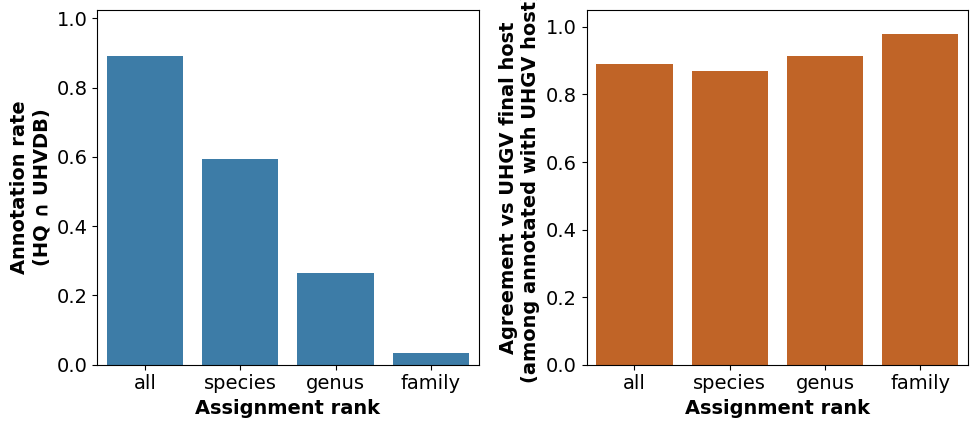

all: annotated 45,765/51,406 (0.890); agreement 0.890 (n_ref=32,250)
species: annotated 30,459/51,406 (0.593); agreement 0.870 (n_ref=19,885)
genus: annotated 13,581/51,406 (0.264); agreement 0.914 (n_ref=10,879)
family: annotated 1,725/51,406 (0.034); agreement 0.978 (n_ref=1,486)


In [105]:
### Plot annotation rate and agreement rate by assignment rank
plot_df = (
    benchmark
    .with_columns(
        pl.col('set').replace({'all assignments': 'all'})
    )
    .to_pandas()
)
plot_df['set'] = pd.Categorical(plot_df['set'], categories=['all', 'species', 'genus', 'family'], ordered=True)
plot_df = plot_df.sort_values('set')

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

sns.barplot(data=plot_df, x='set', y='annotation_rate', color='#2c7fb8', ax=axes[0])
axes[0].set_ylabel('Annotation rate\n(HQ ∩ UHVDB)', fontdict={'fontweight': 'bold'})
axes[0].set_xlabel('Assignment rank', fontdict={'fontweight': 'bold'})
axes[0].set_ylim(0, max(plot_df['annotation_rate'].max() * 1.15, 0.05))

sns.barplot(data=plot_df, x='set', y='agreement_rate', color='#d95f0e', ax=axes[1])
axes[1].set_ylabel('Agreement vs UHGV final host\n(among annotated with UHGV host)', fontdict={'fontweight': 'bold'})
axes[1].set_xlabel('Assignment rank', fontdict={'fontweight': 'bold'})
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

for _, row in plot_df.iterrows():
    agr = row['agreement_rate']
    agr_s = f'{agr:.3f}' if agr == agr else 'NA'
    print(
        f"{row['set']}: annotated {int(row['n_hq_annotated']):,}/{n_hq_both:,} "
        f"({row['annotation_rate']:.3f}); agreement {agr_s} "
        f"(n_ref={int(row['n_with_uhgv_host_ref']):,})"
    )

In [106]:
### Identify viruses assigned to ICTV classes with eukaryotic hosts
# Classes containing eukaryotic-host viruses = all ICTV classes except known
# prokaryote-only phage classes (Caudoviricetes, Microviridae, etc.).

ictv_rows = (
    pl.read_csv(ICTV_TSV, separator='\t')
    .select(['uhvdb_id', 'Class', 'Family', 'taxonomy'])
    .with_columns(
        (~pl.col('Class').is_in(list(PROKARYOTE_ONLY_ICTV_CLASSES))).alias('euk_host_class')
    )
)
# Per virus: eukaryotic-host class if ANY assigned class contains eukaryotic viruses
ictv = (
    ictv_rows
    .group_by('uhvdb_id')
    .agg([
        pl.col('euk_host_class').any().alias('euk_host_class'),
        pl.col('Class').unique().alias('classes'),
        pl.col('Class')
          .filter(pl.col('euk_host_class'))
          .unique()
          .alias('euk_classes'),
    ])
)

assigned_ids = set(host_assignments['uhvdb_id'].to_list())
# Viruses considered for CRISPR/PHIST assignment (any method call at any rank)
eligible_ids = set(combined['uhvdb_id'].unique().to_list())

ictv_annot = ictv.with_columns([
    pl.col('uhvdb_id').is_in(list(assigned_ids)).alias('has_crispr_phist_host'),
    pl.col('uhvdb_id').is_in(list(eligible_ids)).alias('crispr_phist_eligible'),
])

euk = ictv_annot.filter(pl.col('euk_host_class'))
n_euk = euk.height
n_euk_with_host = euk.filter(pl.col('has_crispr_phist_host')).height
n_euk_without_host = n_euk - n_euk_with_host

# Among all viruses lacking a CRISPR/PHIST host (eligible but unassigned, or all ICTV without host)
no_host_eligible = ictv_annot.filter(
    pl.col('crispr_phist_eligible') & ~pl.col('has_crispr_phist_host')
)
no_host_ictv = ictv_annot.filter(~pl.col('has_crispr_phist_host'))
n_no_host_eligible = no_host_eligible.height
n_no_host_eligible_euk = no_host_eligible.filter(pl.col('euk_host_class')).height
n_no_host_ictv = no_host_ictv.height
n_no_host_ictv_euk = no_host_ictv.filter(pl.col('euk_host_class')).height

euk_class_list = sorted({
    c for classes in euk['euk_classes'].to_list() for c in (classes or [])
})
print('ICTV eukaryotic-host classes:', euk_class_list)
print(f'\nViruses in eukaryotic-host ICTV classes: {n_euk:,}')
print(
    f'  1) Received CRISPR/PHIST host: {n_euk_with_host:,} '
    f'({n_euk_with_host / n_euk:.1%} of euk-class viruses)'
)
print(
    f'  2) Without CRISPR/PHIST host:  {n_euk_without_host:,} '
    f'({n_euk_without_host / n_euk:.1%} of euk-class viruses)'
)

print('\nEnrichment among viruses without CRISPR/PHIST host:')
if n_no_host_eligible > 0:
    print(
        f'  Of CRISPR/PHIST-eligible but unassigned ({n_no_host_eligible:,}): '
        f'{n_no_host_eligible_euk:,} ({n_no_host_eligible_euk / n_no_host_eligible:.1%}) '
        f'are in eukaryotic-host classes'
    )
else:
    print('  No CRISPR/PHIST-eligible unassigned viruses.')
print(
    f'  Of all ICTV-annotated without host ({n_no_host_ictv:,}): '
    f'{n_no_host_ictv_euk:,} ({n_no_host_ictv_euk / n_no_host_ictv:.1%}) '
    f'are in eukaryotic-host classes'
)

print('\nBy ICTV class (row-level eukaryotic-host class hits):')
print(
    ictv_rows
    .filter(pl.col('euk_host_class'))
    .unique(subset=['uhvdb_id', 'Class'])
    .with_columns(
        pl.col('uhvdb_id').is_in(list(assigned_ids)).alias('has_crispr_phist_host')
    )
    .group_by('Class')
    .agg([
        pl.len().alias('n_viruses'),
        pl.col('has_crispr_phist_host').sum().alias('n_with_host'),
    ])
    .with_columns(
        (pl.col('n_viruses') - pl.col('n_with_host')).alias('n_without_host'),
        (pl.col('n_with_host') / pl.col('n_viruses')).alias('frac_with_host'),
    )
    .sort('n_viruses', descending=True)
)


ICTV eukaryotic-host classes: ['Alsuviricetes', 'Arfiviricetes', 'Cardeaviricetes', 'Chrymotiviricetes', 'Naldaviricetes', 'Papovaviricetes', 'Pisoniviricetes', 'Quintoviricetes', 'Repensiviricetes', 'Revtraviricetes', 'Stelpaviricetes', 'Tolucaviricetes']

Viruses in eukaryotic-host ICTV classes: 1,460
  1) Received CRISPR/PHIST host: 76 (5.2% of euk-class viruses)
  2) Without CRISPR/PHIST host:  1,384 (94.8% of euk-class viruses)

Enrichment among viruses without CRISPR/PHIST host:
  Of CRISPR/PHIST-eligible but unassigned (5,952): 5 (0.1%) are in eukaryotic-host classes
  Of all ICTV-annotated without host (35,312): 1,384 (3.9%) are in eukaryotic-host classes

By ICTV class (row-level eukaryotic-host class hits):
shape: (12, 5)
┌───────────────────┬───────────┬─────────────┬────────────────┬────────────────┐
│ Class             ┆ n_viruses ┆ n_with_host ┆ n_without_host ┆ frac_with_host │
│ ---               ┆ ---       ┆ ---         ┆ ---            ┆ ---            │
│ str       